# Lecture 29: Delzant Construction

**Source span.** Printed pages 181-188; physical PDF pages 195-202 in `Lectures on Symplectic Geometry.pdf`.

**Chapter goal.** Lecture 28 stated that Delzant polytopes classify compact symplectic toric manifolds. This lecture supplies the construction proof: start with the facet normals, build the exact sequence of tori, cut out the zero level `Z`, prove compactness and freeness, reduce by the kernel torus `N`, and recover a Hamiltonian `T^n`-space whose moment image is the original polytope.

This notebook makes the proof executable for the standard two-simplex model. It checks the algebraic setup, visualizes `phi(Z)=Delta0`, turns the face stratification into zero-coordinate rules, verifies the freeness mechanism at vertices, shows the affine-plane intersection with the negative orthant, and ends with the orbit-space picture of collapsing torus directions over faces.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import networkx as nx
import numpy as np
import sympy as sp
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import Image, display


def find_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "artifacts").is_dir():
            return candidate
    raise RuntimeError("Could not locate LSG course root.")


BOOK_ROOT = find_root()
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "lecture-29"
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
for folder in (FIGURES, CHECKS):
    folder.mkdir(parents=True, exist_ok=True)


def rel(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()


def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def display_artifact(relative_path: str, *, width: int = 760) -> None:
    display(Image(filename=str(BOOK_ROOT / relative_path), width=width))


source_span = {
    "lecture": 29,
    "title": "Delzant Construction",
    "printed_pages": "181-188",
    "physical_pdf_pages": "195-202",
    "source_note": (
        "Inspected the local PDF text for the algebraic setup, zero-level compactness "
        "and freeness proof, conclusion of the Delzant construction, affine-plane "
        "model, orbit-space interpretation, S^2 cylinder collapse example, and Homework 22 themes."
    ),
}
write_json(CHECKS / "source-span.json", source_span)
source_span

{'lecture': 29,
 'title': 'Delzant Construction',
 'printed_pages': '181-188',
 'physical_pdf_pages': '195-202',
 'source_note': 'Inspected the local PDF text for the algebraic setup, zero-level compactness and freeness proof, conclusion of the Delzant construction, affine-plane model, orbit-space interpretation, S^2 cylinder collapse example, and Homework 22 themes.'}

## Translation Guide

`Algebraic setup` means the facet-normal map `pi: R^d -> R^n`, its kernel `n`, and the dual sequence that supplies the projection `i*: (R^d)^* -> n^*`. The standard `T^d` action on `C^d` has a moment map `phi`; restricting the action to `N=ker(pi)` gives the moment map `i* phi`.

`Zero level` means `Z=(i* phi)^{-1}(0)`. The proof of compactness is the identity `phi(Z)=Delta0=pi*(Delta)`: the image is compact, and `phi` is proper. The proof of freeness is local over faces. If a face is defined by active equations indexed by `I`, then the source calculation gives `z_i=0` exactly for those indices. Stabilizers are largest over vertices, and the Delzant smoothness condition makes `pi` identify that stabilizer torus with `T^n`, so its intersection with `N` is trivial.

`Conclusion` means the reduced space `M_Delta=Z/N` carries a reduced symplectic form and a residual Hamiltonian `T^n` action. The residual moment image is `Delta`.

`Universal negative orthant model` means `Delta` is isomorphic to an affine plane `A` intersected with `R^d_-`; this explains why the standard moment map on `C^d` is the universal source for the construction.

## Library Routing

Matplotlib provides the coordinate pictures: the lifted polytope, strata, affine-plane cut, and cylinder collapse are visual geometric claims. NetworkX records the proof dependency route. SymPy computes rank, kernel, and active-normal determinants exactly. NumPy checks sample points, zero-level equations, residuals, and orbit-fiber dimensions.

In [2]:
storyboard = {
    "chapter_goal": "Execute the proof of the Delzant construction for a simplex model while preserving the general algebraic route.",
    "source_span_read": source_span,
    "library_routing": [
        {
            "concept": "algebraic setup and exact sequences",
            "representation": "normal matrix, kernel, dual plane checks",
            "library": "SymPy + Matplotlib",
            "why": "the construction starts with exact rank/kernel data",
            "fallback": "matrix table",
        },
        {
            "concept": "phi(Z)=Delta0 compactness proof",
            "representation": "3D lifted triangle in im(pi*)",
            "library": "Matplotlib 3D + NumPy",
            "why": "compactness follows from a visible compact lifted polytope",
            "fallback": "sample residual table",
        },
        {
            "concept": "face stratification and orbit types",
            "representation": "faces labeled by active indices and zero coordinates",
            "library": "Matplotlib",
            "why": "the source proof identifies faces with coordinates z_i=0",
            "fallback": "face-index ledger",
        },
        {
            "concept": "free N-action at worst stabilizers",
            "representation": "vertex determinant/stabilizer diagram",
            "library": "NetworkX + SymPy",
            "why": "freeness is a proof route using the Delzant basis condition",
            "fallback": "determinant list",
        },
        {
            "concept": "negative orthant and orbit-space visualization",
            "representation": "affine-plane cut plus S^1 x interval collapse",
            "library": "Matplotlib",
            "why": "the final section is a geometric mental model of the construction",
            "fallback": "diagrammatic ledger",
        },
    ],
    "visual_sequence": [
        {
            "concept": "Algebraic setup from facet normals",
            "artifact": rel(FIGURES / "delzant-setup-exact-sequences.png"),
            "inspection_target": "see pi, ker(pi), pi*(Delta), and the dimension counts",
            "validation": "rank(pi)=2, kernel dimension=1, im(pi*) plane residuals vanish",
        },
        {
            "concept": "Compactness proof phi(Z)=Delta0",
            "artifact": rel(FIGURES / "phi-Z-equals-lifted-polytope.png"),
            "inspection_target": "compare Delta and its lifted triangle Delta0 in the plane y1+y2+y3=0",
            "validation": "sample points satisfy y=pi*(x), y<=lambda, and kernel pairing zero",
        },
        {
            "concept": "Face stratification and zero-coordinate rule",
            "artifact": rel(FIGURES / "face-strata-zero-coordinate-rule.png"),
            "inspection_target": "match active face index I with the coordinates z_i forced to zero",
            "validation": "each active facet has phi_i=lambda_i exactly when z_i=0",
        },
        {
            "concept": "Freeness mechanism at vertices",
            "artifact": rel(FIGURES / "free-N-action-vertex-stabilizers.png"),
            "inspection_target": "follow why the largest stabilizers still miss N",
            "validation": "active normal determinants have absolute value one",
        },
        {
            "concept": "Universal orthant and toric orbit-space collapse",
            "artifact": rel(FIGURES / "negative-orthant-and-cylinder-collapse.png"),
            "inspection_target": "see Delta as A intersect R_-^d and S^2 as a collapsed S^1 x interval",
            "validation": "affine-plane inequalities match the original polytope",
        },
    ],
}
write_json(CHECKS / "visual-storyboard.json", storyboard)
print("planned visuals:", len(storyboard["visual_sequence"]))

planned visuals: 5


## Algebraic Setup

For the standard simplex, take primitive outward normals `v1=(-1,0)`, `v2=(0,-1)`, `v3=(1,1)` and constants `lambda=(0,0,1)`. The map `pi: R^3 -> R^2` has these normals as columns. Its kernel is one-dimensional, and the image of the dual map `pi*` is the plane `y1+y2+y3=0` in `(R^3)^*`.

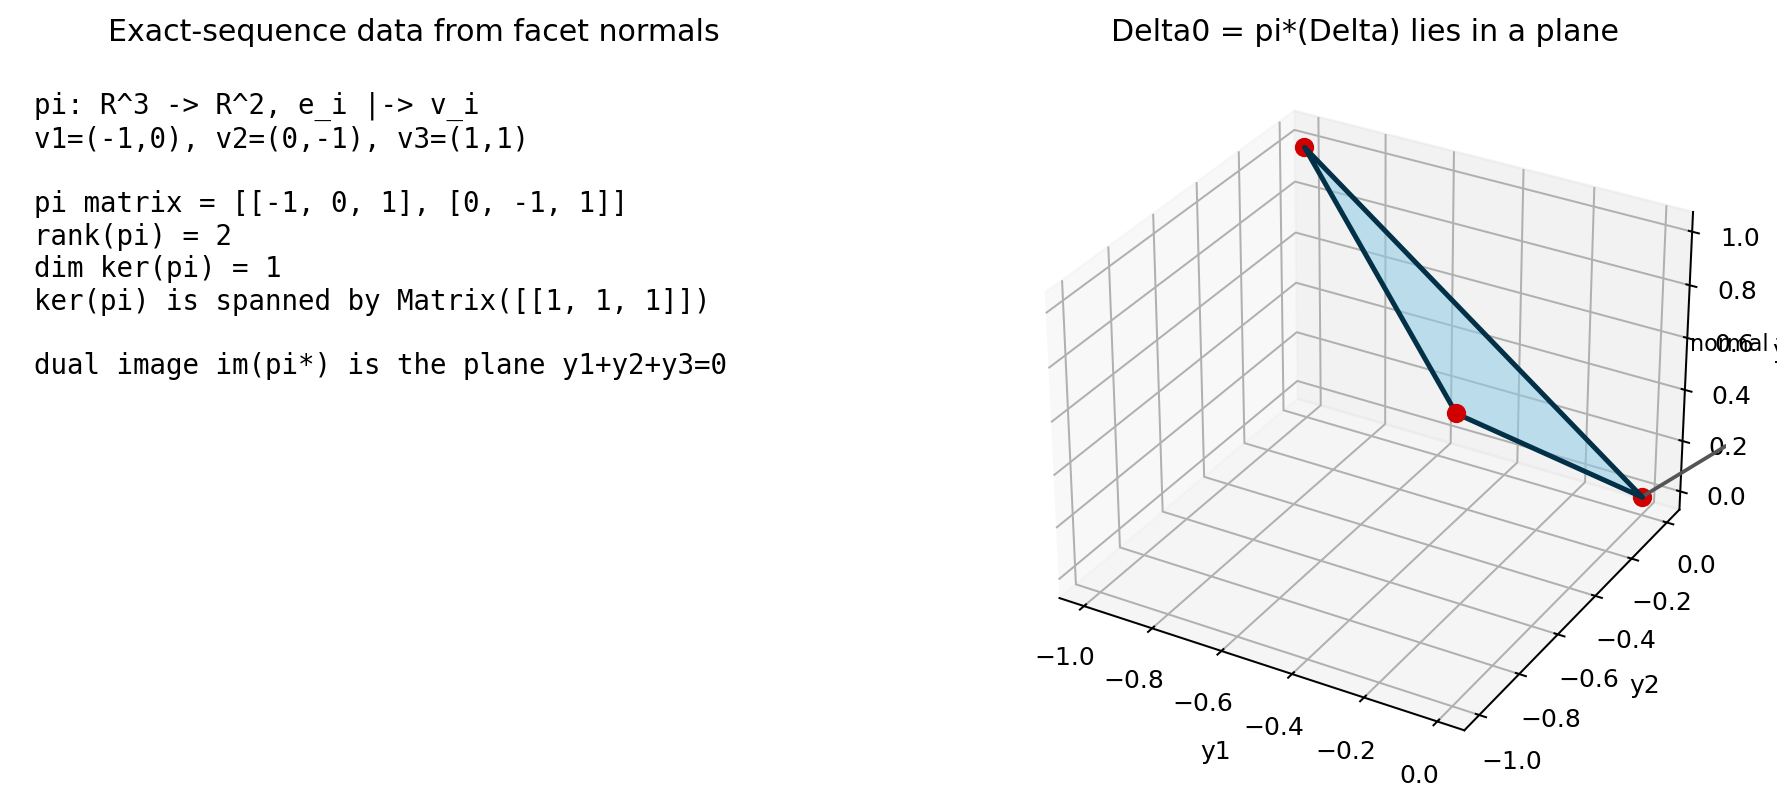

In [3]:
Pi = sp.Matrix([[-1, 0, 1], [0, -1, 1]])
lambda_vec = np.array([0.0, 0.0, 1.0])
rank_pi = int(Pi.rank())
kernel_basis = Pi.nullspace()
kernel_dim = len(kernel_basis)
kernel_vector = np.array(kernel_basis[0], dtype=float).reshape(3)
kernel_vector = kernel_vector / np.linalg.norm(kernel_vector)
Pi_np = np.array(Pi, dtype=float)

simplex_vertices = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])
lifted_vertices = np.array([Pi_np.T @ x for x in simplex_vertices])
plane_residuals = lifted_vertices @ np.array([1.0, 1.0, 1.0])

fig = plt.figure(figsize=(12.5, 5.2))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection="3d")
ax1.axis("off")
setup_text = (
    "pi: R^3 -> R^2, e_i |-> v_i\n"
    "v1=(-1,0), v2=(0,-1), v3=(1,1)\n\n"
    f"pi matrix = {Pi.tolist()}\n"
    f"rank(pi) = {rank_pi}\n"
    f"dim ker(pi) = {kernel_dim}\n"
    f"ker(pi) is spanned by {kernel_basis[0].T}\n\n"
    "dual image im(pi*) is the plane y1+y2+y3=0"
)
ax1.text(0.02, 0.95, setup_text, family="monospace", fontsize=11, va="top")
ax1.set_title("Exact-sequence data from facet normals")

ax2.add_collection3d(Poly3DCollection([lifted_vertices], facecolor="#8ecae6", edgecolor="#023047", alpha=0.55, linewidth=2))
for yv in lifted_vertices:
    ax2.scatter(*yv, color="#d00000", s=45)
ax2.quiver(0, 0, 0, *kernel_vector, color="#555555", length=0.8, arrow_length_ratio=0.15)
ax2.text(0.08, 0.08, 0.55, "normal to im(pi*)", fontsize=9)
ax2.set_xlabel("y1")
ax2.set_ylabel("y2")
ax2.set_zlabel("y3")
ax2.set_title("Delta0 = pi*(Delta) lies in a plane")
setup_path = FIGURES / "delzant-setup-exact-sequences.png"
fig.savefig(setup_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert rank_pi == 2
assert kernel_dim == 1
assert np.max(np.abs(plane_residuals)) < 1e-12
display_artifact(rel(setup_path))

## Compactness: `phi(Z)=Delta0`

The source proof shows that a point `y` is in the image of `Z` by `phi` exactly when two conditions hold: `y` is in the image of the standard moment map, and `i*y=0`. For the simplex model, this means `y_i <= lambda_i` and `y1+y2+y3=0`, so `y=pi*(x)` for some `x` in the original simplex. Since `Delta0` is compact and `phi` is proper, `Z` is compact.

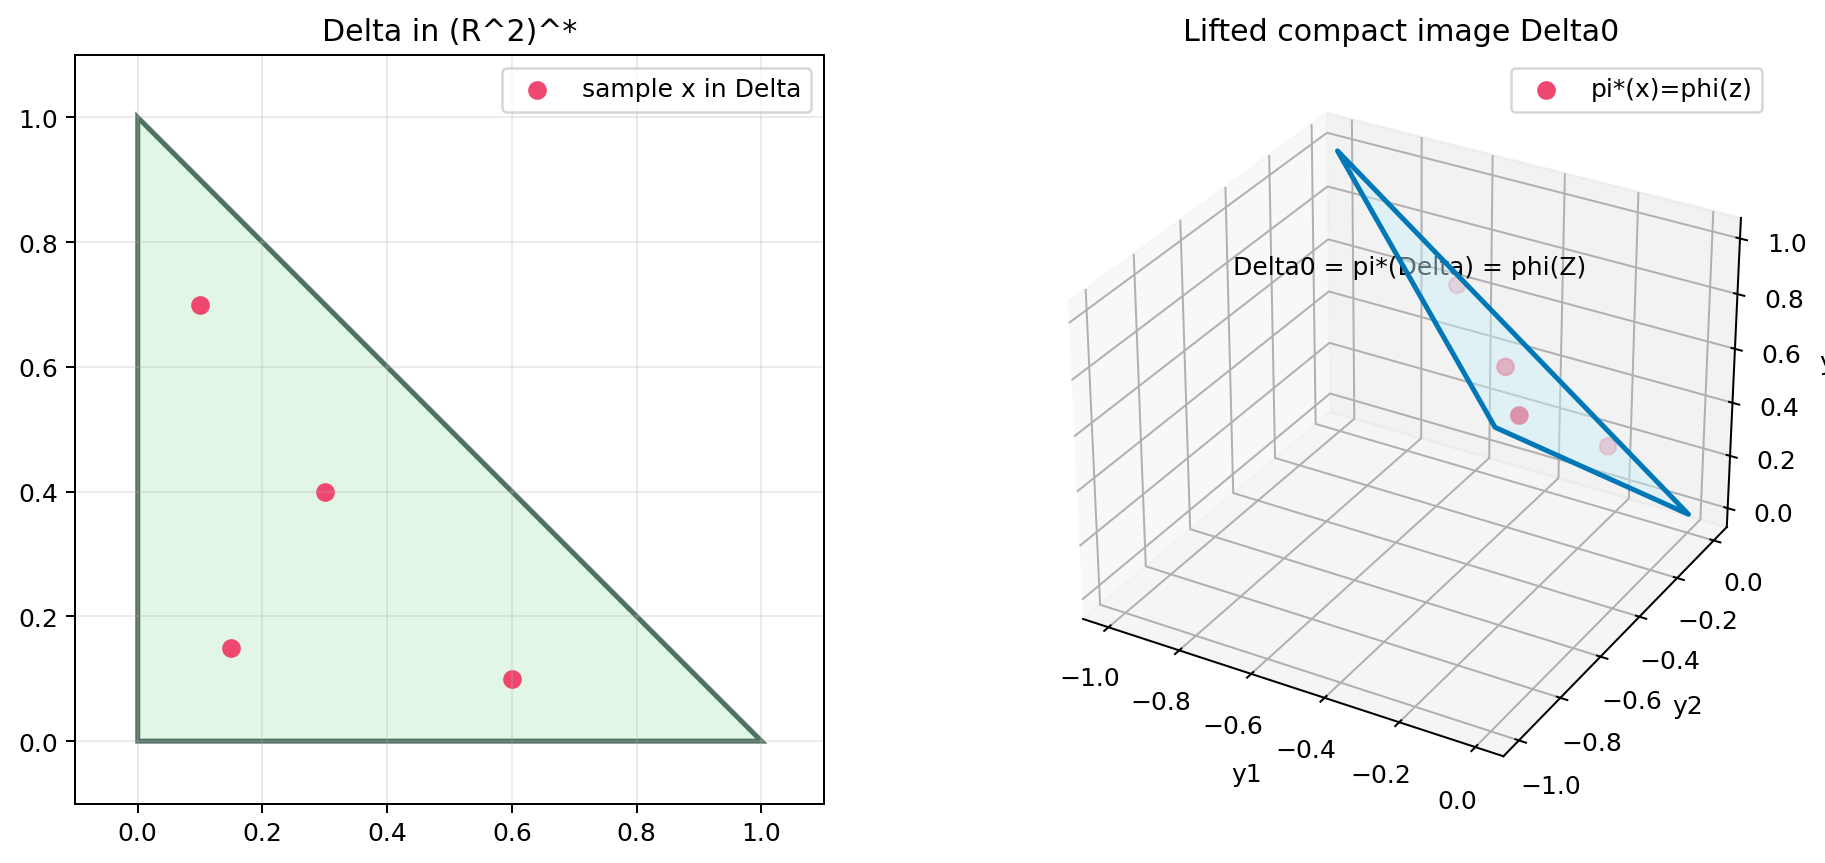

In [4]:
sample_points = np.array([[0.15, 0.15], [0.6, 0.1], [0.1, 0.7], [0.3, 0.4]])
sample_y = np.array([Pi_np.T @ x for x in sample_points])
sample_r2 = 2 * (lambda_vec - sample_y)
kernel_pairing_residual = float(np.max(np.abs(sample_y @ np.array([1.0, 1.0, 1.0]))))
halfspace_residual = float(np.max(sample_y - lambda_vec))
radius_nonnegative = bool(np.min(sample_r2) >= -1e-12)

fig = plt.figure(figsize=(12.5, 5.4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection="3d")
ax1.add_patch(Polygon(simplex_vertices, closed=True, facecolor="#d8f3dc", edgecolor="#1b4332", linewidth=2, alpha=0.75))
ax1.scatter(sample_points[:, 0], sample_points[:, 1], color="#ef476f", s=42, label="sample x in Delta")
ax1.set_title("Delta in (R^2)^*")
ax1.set_aspect("equal")
ax1.set_xlim(-0.1, 1.1)
ax1.set_ylim(-0.1, 1.1)
ax1.grid(True, alpha=0.25)
ax1.legend()

ax2.add_collection3d(Poly3DCollection([lifted_vertices], facecolor="#caf0f8", edgecolor="#0077b6", alpha=0.45, linewidth=2))
ax2.scatter(sample_y[:, 0], sample_y[:, 1], sample_y[:, 2], color="#ef476f", s=42, label="pi*(x)=phi(z)")
ax2.text(-0.8, -0.8, 1.1, "Delta0 = pi*(Delta) = phi(Z)", fontsize=10)
ax2.set_xlabel("y1")
ax2.set_ylabel("y2")
ax2.set_zlabel("y3")
ax2.set_title("Lifted compact image Delta0")
ax2.legend()
compact_path = FIGURES / "phi-Z-equals-lifted-polytope.png"
fig.savefig(compact_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert kernel_pairing_residual < 1e-12
assert halfspace_residual <= 1e-12
assert radius_nonnegative
display_artifact(rel(compact_path))

## Face Stratification And Orbit Types

The source gives three equivalent descriptions of the stratification. In the computational model the useful rule is:

`phi(z)` lies on the facet indexed by `i` if and only if `phi_i(z)=lambda_i`, and because `phi_i=lambda_i - |z_i|^2/2`, this is equivalent to `z_i=0`.

Thus faces of `Delta0` encode which complex coordinates vanish. The same index set also controls the `T^d` stabilizer type.

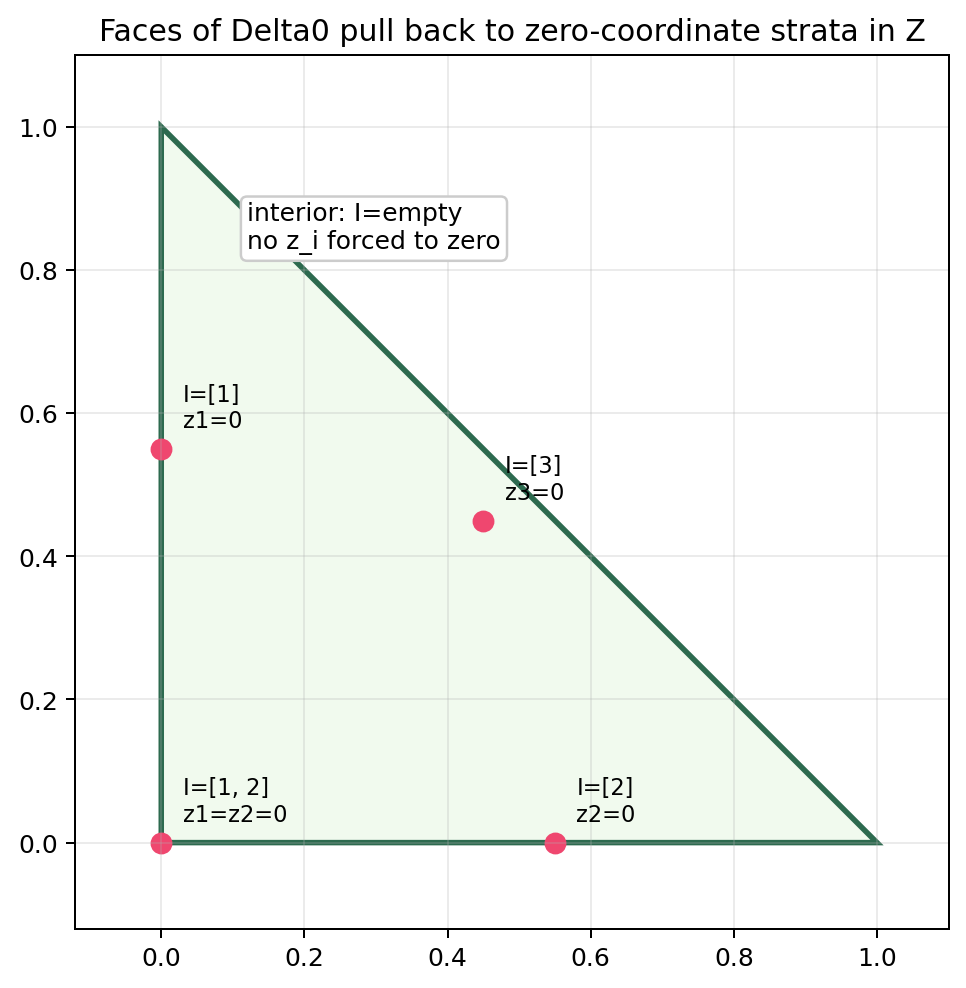

In [5]:
faces = [
    {"name": "facet 1", "I": [1], "midpoint": np.array([0.0, 0.55]), "zero_rule": "z1=0"},
    {"name": "facet 2", "I": [2], "midpoint": np.array([0.55, 0.0]), "zero_rule": "z2=0"},
    {"name": "facet 3", "I": [3], "midpoint": np.array([0.45, 0.45]), "zero_rule": "z3=0"},
    {"name": "vertex", "I": [1, 2], "midpoint": np.array([0.0, 0.0]), "zero_rule": "z1=z2=0"},
]
face_checks = {}
test_radii = np.array([0.0, math.sqrt(0.7), math.sqrt(0.9)])
phi_test = lambda_vec - 0.5 * test_radii**2
face_checks["facet_1_phi_equals_lambda_when_z1_zero"] = abs(phi_test[0] - lambda_vec[0]) < 1e-12
face_checks["other_coordinates_can_be_nonzero"] = bool(test_radii[1] > 0 and test_radii[2] > 0)

fig, ax = plt.subplots(figsize=(7.5, 6.3))
ax.add_patch(Polygon(simplex_vertices, closed=True, facecolor="#f1faee", edgecolor="#2d6a4f", linewidth=2.2))
for face in faces:
    xy = face["midpoint"]
    ax.scatter(*xy, s=60, color="#ef476f")
    ax.annotate(f"I={face['I']}\n{face['zero_rule']}", xy + np.array([0.03, 0.03]), fontsize=9)
ax.text(0.12, 0.83, "interior: I=empty\nno z_i forced to zero", fontsize=10, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#cccccc"))
ax.set_title("Faces of Delta0 pull back to zero-coordinate strata in Z")
ax.set_aspect("equal")
ax.set_xlim(-0.12, 1.1)
ax.set_ylim(-0.12, 1.1)
ax.grid(True, alpha=0.25)
strata_path = FIGURES / "face-strata-zero-coordinate-rule.png"
fig.savefig(strata_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert all(face_checks.values())
display_artifact(rel(strata_path))

## Freeness Of The Kernel Torus

The source proves freeness by checking the worst stabilizers, which occur above vertices. At a vertex, the active normals form a lattice basis by the Delzant smoothness condition. Therefore the map from the corresponding coordinate stabilizer torus to `T^n` is bijective, and the stabilizer intersects `N=ker(pi)` only in the identity.

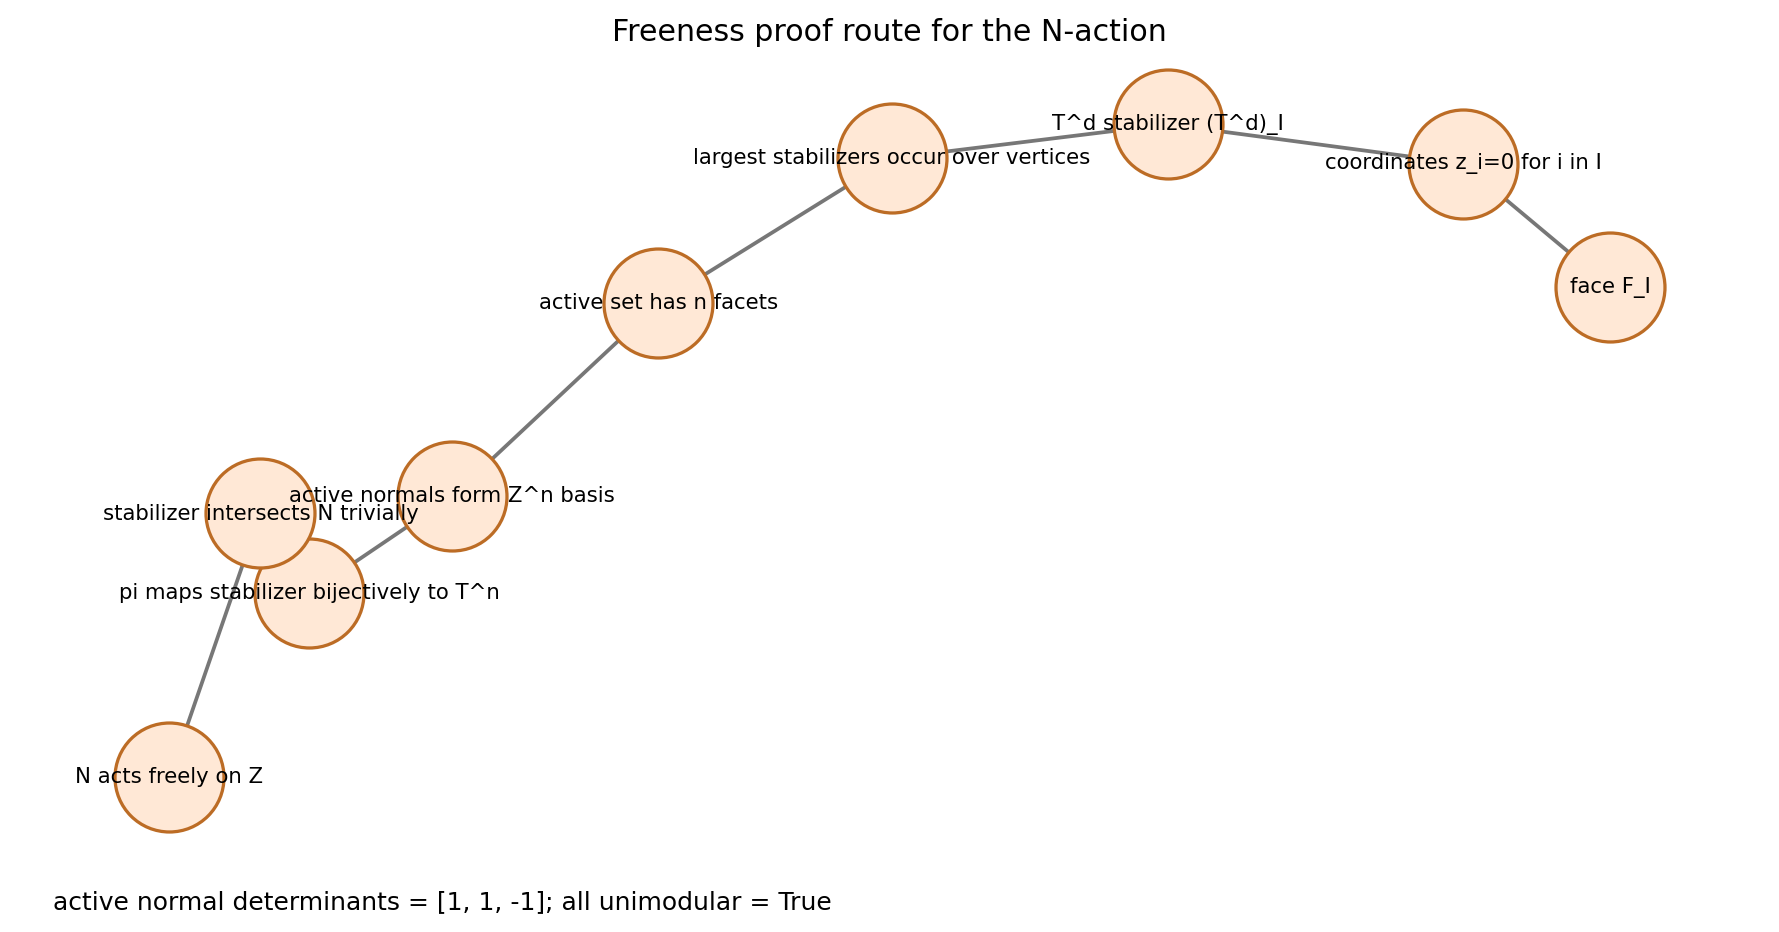

In [6]:
active_normal_pairs = [
    [(-1, 0), (0, -1)],
    [(0, -1), (1, 1)],
    [(-1, 0), (1, 1)],
]
active_determinants = [int(round(np.linalg.det(np.array(pair, dtype=float)))) for pair in active_normal_pairs]
vertex_unimodular = [abs(det) == 1 for det in active_determinants]

proof = nx.DiGraph()
proof_edges = [
    ("face F_I", "coordinates z_i=0 for i in I"),
    ("coordinates z_i=0 for i in I", "T^d stabilizer (T^d)_I"),
    ("T^d stabilizer (T^d)_I", "largest stabilizers occur over vertices"),
    ("largest stabilizers occur over vertices", "active set has n facets"),
    ("active set has n facets", "active normals form Z^n basis"),
    ("active normals form Z^n basis", "pi maps stabilizer bijectively to T^n"),
    ("pi maps stabilizer bijectively to T^n", "stabilizer intersects N trivially"),
    ("stabilizer intersects N trivially", "N acts freely on Z"),
]
proof.add_edges_from(proof_edges)
pos = nx.spring_layout(proof, seed=7)
fig, ax = plt.subplots(figsize=(12.5, 5.7))
nx.draw_networkx_edges(proof, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.5, edge_color="#777777")
nx.draw_networkx_nodes(proof, pos, ax=ax, node_color="#ffe8d6", edgecolors="#bc6c25", node_size=1900, linewidths=1.3)
nx.draw_networkx_labels(proof, pos, ax=ax, font_size=8.5)
ax.text(0.02, -0.08, f"active normal determinants = {active_determinants}; all unimodular = {all(vertex_unimodular)}", transform=ax.transAxes, fontsize=10)
ax.set_axis_off()
ax.set_title("Freeness proof route for the N-action")
free_path = FIGURES / "free-N-action-vertex-stabilizers.png"
fig.savefig(free_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert all(vertex_unimodular)
assert nx.has_path(proof, "face F_I", "N acts freely on Z")
display_artifact(rel(free_path))

## Universal Orthant And Orbit-Space Collapse

The last section gives a mental model: every polytope with `d` facets can be obtained as an affine `n`-plane intersecting the negative orthant `R^d_-`. The standard moment map on `C^d` has image `R^d_-`, so the construction pulls the affine cut back, quotients the null foliation, and leaves a toric manifold.

For toric manifolds, the moment polytope is the orbit space. In the sphere example, `S^2` with the height moment map is recovered from `S^1 x [-1,1]` by collapsing the circle over each endpoint. The same rule generalizes: over a face, collapse the torus subgroup corresponding to the missing cotangent directions.

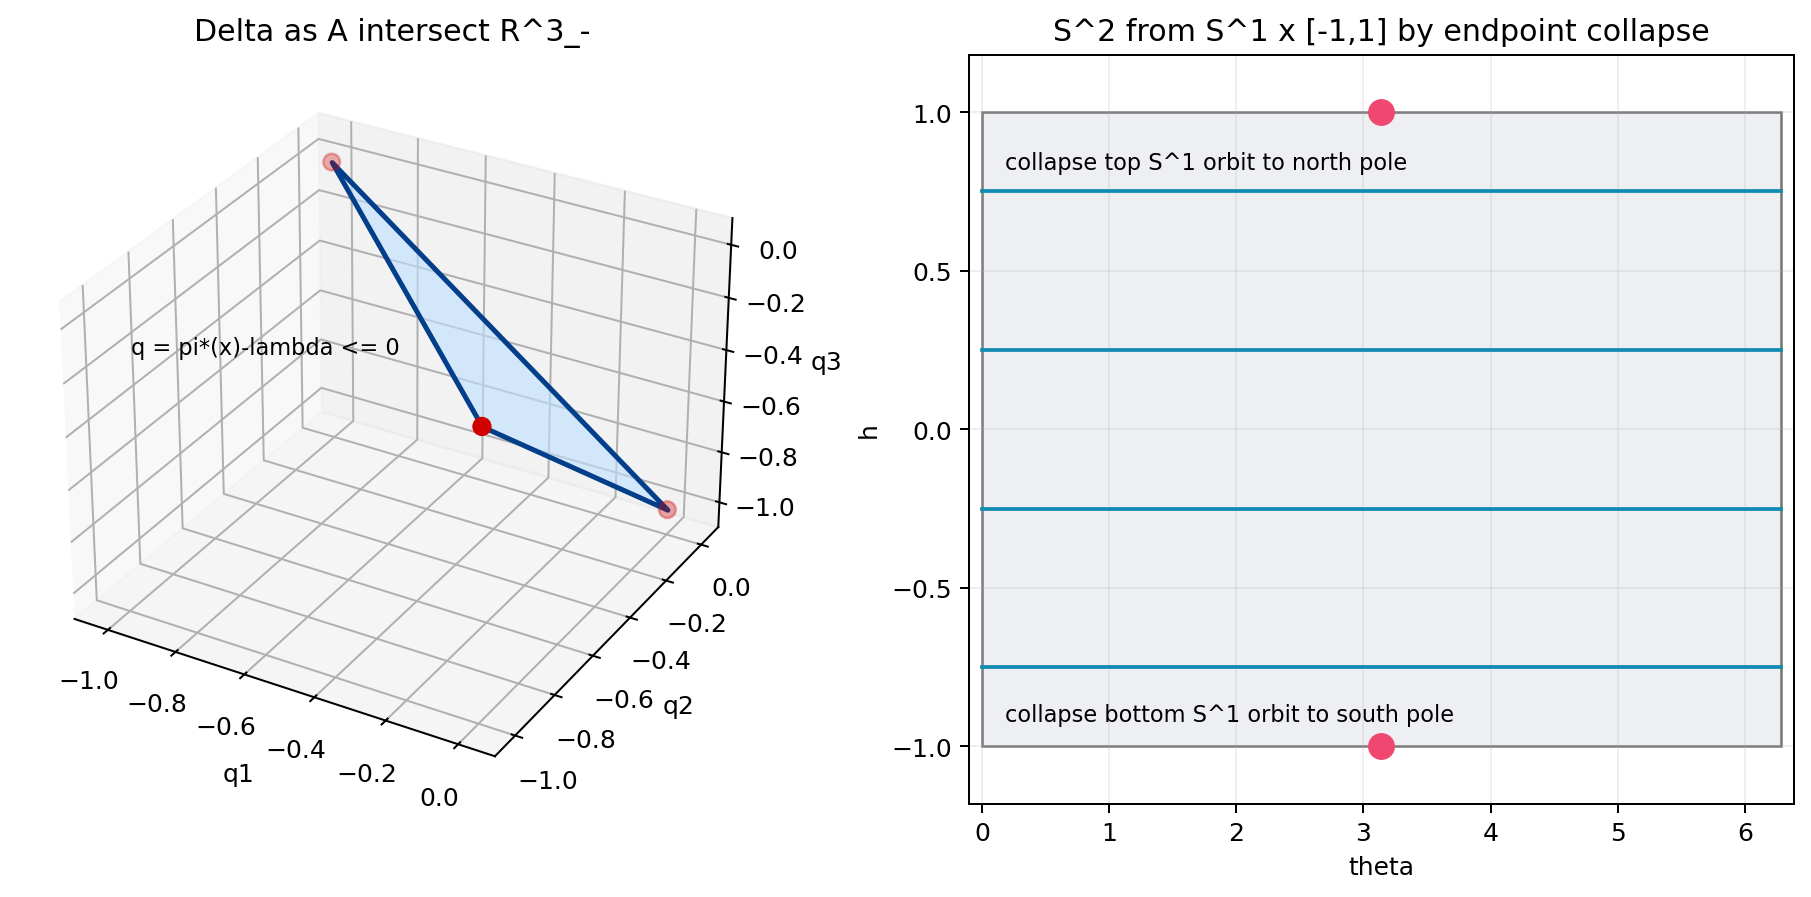

In [7]:
q_vertices = lifted_vertices - lambda_vec
orthant_check = bool(np.max(q_vertices) <= 1e-12)
affine_plane_residual = float(np.max(np.abs((q_vertices + lambda_vec) @ np.array([1.0, 1.0, 1.0]))))

fig = plt.figure(figsize=(13, 5.4))
ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122)
ax1.add_collection3d(Poly3DCollection([q_vertices], facecolor="#bde0fe", edgecolor="#023e8a", alpha=0.6, linewidth=2))
ax1.scatter(q_vertices[:, 0], q_vertices[:, 1], q_vertices[:, 2], color="#d00000", s=45)
ax1.set_xlim(-1.1, 0.1)
ax1.set_ylim(-1.1, 0.1)
ax1.set_zlim(-1.1, 0.1)
ax1.set_xlabel("q1")
ax1.set_ylabel("q2")
ax1.set_zlabel("q3")
ax1.set_title("Delta as A intersect R^3_-")
ax1.text(-1.0, -0.95, -0.15, "q = pi*(x)-lambda <= 0", fontsize=9)

ax2.add_patch(Rectangle((0, -1), 2 * math.pi, 2, facecolor="#e9ecef", edgecolor="#555555", alpha=0.8))
for h in np.linspace(-0.75, 0.75, 4):
    ax2.plot([0, 2 * math.pi], [h, h], color="#118ab2", lw=1.5)
ax2.scatter([math.pi, math.pi], [-1, 1], color="#ef476f", s=95, zorder=4)
ax2.text(0.18, 0.82, "collapse top S^1 orbit to north pole", fontsize=9)
ax2.text(0.18, -0.92, "collapse bottom S^1 orbit to south pole", fontsize=9)
ax2.set_xlim(-0.1, 2 * math.pi + 0.1)
ax2.set_ylim(-1.18, 1.18)
ax2.set_xlabel("theta")
ax2.set_ylabel("h")
ax2.set_title("S^2 from S^1 x [-1,1] by endpoint collapse")
ax2.grid(True, alpha=0.2)
orthant_path = FIGURES / "negative-orthant-and-cylinder-collapse.png"
fig.savefig(orthant_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert orthant_check
assert affine_plane_residual < 1e-12
display_artifact(rel(orthant_path))

## Final Checks

These checks follow the source proof order: exact-sequence rank, compact lifted image, face-stratification rule, freeness by vertex bases, reduced moment image, and orbit-space visualization.

In [8]:
results = {
    "rank_pi": rank_pi,
    "kernel_dimension": kernel_dim,
    "plane_residual_max": float(np.max(np.abs(plane_residuals))),
    "kernel_pairing_residual": kernel_pairing_residual,
    "phi_halfspace_residual": halfspace_residual,
    "sample_radii_nonnegative": bool(radius_nonnegative),
    "face_zero_coordinate_checks": {key: bool(value) for key, value in face_checks.items()},
    "active_normal_determinants": active_determinants,
    "vertex_unimodular": [bool(value) for value in vertex_unimodular],
    "orthant_check": bool(orthant_check),
    "affine_plane_residual": affine_plane_residual,
}
write_json(CHECKS / "delzant-construction-residuals.json", results)

final_sanity = {
    "passed": True,
    "artifacts": [
        rel(FIGURES / "delzant-setup-exact-sequences.png"),
        rel(FIGURES / "phi-Z-equals-lifted-polytope.png"),
        rel(FIGURES / "face-strata-zero-coordinate-rule.png"),
        rel(FIGURES / "free-N-action-vertex-stabilizers.png"),
        rel(FIGURES / "negative-orthant-and-cylinder-collapse.png"),
        rel(CHECKS / "source-span.json"),
        rel(CHECKS / "visual-storyboard.json"),
        rel(CHECKS / "delzant-construction-residuals.json"),
    ],
    "assertions": {
        "pi_full_rank": bool(rank_pi == 2),
        "kernel_dimension_correct": bool(kernel_dim == 1),
        "delta0_plane_residual_small": bool(np.max(np.abs(plane_residuals)) < 1e-12),
        "phiZ_samples_in_delta0": bool(kernel_pairing_residual < 1e-12 and halfspace_residual <= 1e-12 and radius_nonnegative),
        "face_rule_checked": bool(all(face_checks.values())),
        "free_action_vertex_basis_checked": bool(all(vertex_unimodular)),
        "orthant_model_checked": bool(orthant_check and affine_plane_residual < 1e-12),
    },
    "coverage_note": "Covers Lecture 29 sections 29.1-29.4 plus the S2 collapse and Homework 22 themes without copied source prose.",
}
write_json(CHECKS / "final-sanity.json", final_sanity)

for relative_path in final_sanity["artifacts"]:
    artifact = BOOK_ROOT / relative_path
    assert artifact.exists(), relative_path
    assert artifact.stat().st_size > 0, relative_path

for name, ok in final_sanity["assertions"].items():
    assert bool(ok), name

print(json.dumps(final_sanity, indent=2))

{
  "passed": true,
  "artifacts": [
    "artifacts/lecture-29/figures/delzant-setup-exact-sequences.png",
    "artifacts/lecture-29/figures/phi-Z-equals-lifted-polytope.png",
    "artifacts/lecture-29/figures/face-strata-zero-coordinate-rule.png",
    "artifacts/lecture-29/figures/free-N-action-vertex-stabilizers.png",
    "artifacts/lecture-29/figures/negative-orthant-and-cylinder-collapse.png",
    "artifacts/lecture-29/checks/source-span.json",
    "artifacts/lecture-29/checks/visual-storyboard.json",
    "artifacts/lecture-29/checks/delzant-construction-residuals.json"
  ],
  "assertions": {
    "pi_full_rank": true,
    "kernel_dimension_correct": true,
    "delta0_plane_residual_small": true,
    "phiZ_samples_in_delta0": true,
    "face_rule_checked": true,
    "free_action_vertex_basis_checked": true,
    "orthant_model_checked": true
  },
  "coverage_note": "Covers Lecture 29 sections 29.1-29.4 plus the S2 collapse and Homework 22 themes without copied source prose."
}


## Takeaways And Exploration

The Delzant construction is a reduction machine. Facet normals define the torus exact sequence; the standard moment map on `C^d` supplies a universal orthant; the zero level is compact because its image is the compact lifted polytope; the kernel torus acts freely because smooth vertices give unimodular normal bases; and the quotient inherits the symplectic form and residual torus action with image `Delta`.

For a short exploration, replace the simplex normal `(1,1)` by `(1,2)`. The lifted image still exists, but the vertex determinant check fails; that is exactly where smoothness is needed to keep the quotient manifold behavior expected in the theorem.